In [69]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [70]:
pip install fastf1

Note: you may need to restart the kernel to use updated packages.


In [71]:
import fastf1

import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')


https://github.com/melisasvr/2026_f1_predictions.git

In [72]:
import os
os.makedirs('cache', exist_ok=True)
fastf1.Cache.enable_cache('cache')

In [73]:
schedule = fastf1.get_event_schedule(2026)
schedule

,RoundNumber,Country,Location,OfficialEventName,EventDate,EventName,EventFormat,Session1,Session1Date,Session1DateUtc,...,Session3,Session3Date,Session3DateUtc,Session4,Session4Date,Session4DateUtc,Session5,Session5Date,Session5DateUtc,F1ApiSupport
0,0,Bahrain,Bahrain,FORMULA 1 ARAMCO PRE-SEASON TESTING 1 2026,2026-02-13,Pre-Season Testing,testing,Practice 1,2026-02-11 10:00:00+03:00,2026-02-11 07:00:00,...,Practice 3,2026-02-13 10:00:00+03:00,2026-02-13 07:00:00,None,NaT,NaT,None,NaT,NaT,True
1,0,Bahrain,Bahrain,FORMULA 1 ARAMCO PRE-SEASON TESTING 2 2026,2026-02-20,Pre-Season Testing,testing,Practice 1,2026-02-18 10:00:00+03:00,2026-02-18 07:00:00,...,Practice 3,2026-02-20 10:00:00+03:00,2026-02-20 07:00:00,None,NaT,NaT,None,NaT,NaT,True
2,1,Australia,Melbourne,FORMULA 1 QATAR AIRWAYS AUSTRALIAN GRAND PRIX ...,2026-03-08,Australian Grand Prix,conventional,Practice 1,2026-03-06 12:30:00+11:00,2026-03-06 01:30:00,...,Practice 3,2026-03-07 12:30:00+11:00,2026-03-07 01:30:00,Qualifying,2026-03-07 16:00:00+11:00,2026-03-07 05:00:00,Race,2026-03-08 15:00:00+11:00,2026-03-08 04:00:00,True
3,2,China,Shanghai,FORMULA 1 HEINEKEN CHINESE GRAND PRIX 2026,2026-03-15,Chinese Grand Prix,sprint_qualifying,Practice 1,2026-03-13 11:30:00+08:00,2026-03-13 03:30:00,...,Sprint,2026-03-14 11:00:00+08:00,2026-03-14 03:00:00,Qualifying,2026-03-14 15:00:00+08:00,2026-03-14 07:00:00,Race,2026-03-15 15:00:00+08:00,2026-03-15 07:00:00,True
4,3,Japan,Suzuka,FORMULA 1 ARAMCO JAPANESE GRAND PRIX 2026,2026-03-29,Japanese Grand Prix,conventional,Practice 1,2026-03-27 11:30:00+09:00,2026-03-27 02:30:00,...,Practice 3,2026-03-28 11:30:00+09:00,2026-03-28 02:30:00,Qualifying,2026-03-28 15:00:00+09:00,2026-03-28 06:00:00,Race,2026-03-29 14:00:00+09:00,2026-03-29 05:00:00,True
5,4,United States,Miami Gardens,FORMULA 1 CRYPTO.COM MIAMI GRAND PRIX 2026,2026-05-03,Miami Grand Prix,sprint_qualifying,Practice 1,2026-05-01 12:30:00-04:00,2026-05-01 16:30:00,...,Sprint,2026-05-02 12:00:00-04:00,2026-05-02 16:00:00,Qualifying,2026-05-02 16:00:00-04:00,2026-05-02 20:00:00,Race,2026-05-03 16:00:00-04:00,2026-05-03 20:00:00,True
6,5,Canada,Montréal,FORMULA 1 LENOVO GRAND PRIX DU CANADA 2026,2026-05-24,Canadian Grand Prix,sprint_qualifying,Practice 1,2026-05-22 12:30:00-04:00,2026-05-22 16:30:00,...,Sprint,2026-05-23 12:00:00-04:00,2026-05-23 16:00:00,Qualifying,2026-05-23 16:00:00-04:00,2026-05-23 20:00:00,Race,2026-05-24 16:00:00-04:00,2026-05-24 20:00:00,True
7,6,Monaco,Monte Carlo,FORMULA 1 LOUIS VUITTON GRAND PRIX DE MONACO 2026,2026-06-07,Monaco Grand Prix,conventional,Practice 1,2026-06-05 13:30:00+02:00,2026-06-05 11:30:00,...,Practice 3,2026-06-06 12:30:00+02:00,2026-06-06 10:30:00,Qualifying,2026-06-06 16:00:00+02:00,2026-06-06 14:00:00,Race,2026-06-07 15:00:00+02:00,2026-06-07 13:00:00,True
8,7,Spain,Barcelona,FORMULA 1 MSC CRUISES GRAN PREMIO DE BARCELONA...,2026-06-14,Barcelona Grand Prix,conventional,Practice 1,2026-06-12 13:30:00+02:00,2026-06-12 11:30:00,...,Practice 3,2026-06-13 12:30:00+02:00,2026-06-13 10:30:00,Qualifying,2026-06-13 16:00:00+02:00,2026-06-13 14:00:00,Race,2026-06-14 15:00:00+02:00,2026-06-14 13:00:00,True
9,8,Austria,Spielberg,FORMULA 1 LENOVO AUSTRIAN GRAND PRIX 2026,2026-06-28,Austrian Grand Prix,conventional,Practice 1,2026-06-26 13:30:00+02:00,2026-06-26 11:30:00,...,Practice 3,2026-06-27 12:30:00+02:00,2026-06-27 10:30:00,Qualifying,2026-06-27 16:00:00+02:00,2026-06-27 14:00:00,Race,2026-06-28 15:00:00+02:00,2026-06-28 13:00:00,True


## 2026 qualifying data (real Q3 results - soft tyres)


In [74]:
# IN CELSIUS
QUALI_TEMP = 22
RACE_TEMP = 27
TEMP_DELTA = RACE_TEMP - QUALI_TEMP

In [75]:
qualifying_2026 = pd.DataFrame({
    "Driver": [
        "George Russell",
        "Kimi Antonelli",
        "Isack Hadjar",
        "Charles Leclerc",
        "Oscar Piastri",
        "Lando Norris",
        "Lewis Hamilton",
        "Liam Lawson",
        "Gabriel Bortoleto",
        "Arvid Lindblad",
    ],
    "GridPosition": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "QualiTime_s": [
        78.518,   # 1:18.518 — Russell  POLE
        78.811,   # 1:18.811 — Antonelli
        79.303,   # 1:19.303 — Hadjar
        79.327,   # 1:19.327 — Leclerc
        79.380,   # 1:19.380 — Piastri
        79.475,   # 1:19.475 — Norris
        79.478,   # 1:19.478 — Hamilton
        79.994,   # 1:19.994 — Lawson
        80.221,   # 1:20.221 — Bortoleto
        81.247,   # 1:21.247 — Lindblad
    ],
    "Team":[
        "Mercedes", "Mercedes", "Red Bull Racing",
        "Ferrari",  "McLaren",  "McLaren",
        "Ferrari",  "Racing Bulls", "Audi", "Racing Bulls",
    ],
    "IsRookie": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],  # Only Lindblad
})

In [76]:
POLE_TIME = qualifying_2026['QualiTime_s'].min()
qualifying_2026["GapToPole_s"] = (
    qualifying_2026["QualiTime_s"] - POLE_TIME
)

In [77]:
TEAM_COLORS = {
    "Mercedes":      "#00D2BE",
    "McLaren":       "#FF8000",
    "Ferrari":       "#DC0000",
    "Red Bull Racing": "#3671C6",
    "Racing Bulls":  "#6692FF",
    "Aston Martin":  "#358C75",
    "Alpine":        "#FF87BC",
    "Williams":      "#64C4FF",
    "Haas":          "#B6BABD",
    "Audi":          "#B8B8B8",
    "Cadillac":      "#C8102E",
}

In [78]:
# ══════════════════════════════════════════════════════════
# 3. TEAM PERFORMANCE TIER  (1 = strongest → 5 = weakest)
#    Based on 2025 constructors standings + 2026 pre-season
# ══════════════════════════════════════════════════════════
TEAM_TIER = {
    "Mercedes":        1,
    "McLaren":         1,
    "Ferrari":         2,
    "Red Bull Racing": 2,
    "Racing Bulls":    3,
    "Aston Martin":    3,
    "Alpine":          4,
    "Williams":        4,
    "Haas":            4,
    "Audi":            5,
    "Cadillac":        5,
}
qualifying_2026["TeamTier"] = qualifying_2026["Team"].map(TEAM_TIER)

In [79]:
# ══════════════════════════════════════════════════════════
# 4. TYRE DEG & HEAT STRESS
#    Lower = better tyre management in heat
# ══════════════════════════════════════════════════════════
TYRE_DEG = {
    "Mercedes":        2,
    "McLaren":         1,
    "Ferrari":         2,
    "Red Bull Racing": 2,
    "Racing Bulls":    3,
    "Aston Martin":    3,
    "Alpine":          3,
    "Williams":        4,
    "Haas":            4,
    "Audi":            4,
    "Cadillac":        5,
}
qualifying_2026["TyreDegSensitivity"] = qualifying_2026["Team"].map(TYRE_DEG)
qualifying_2026["HeatStressScore"] = (
    TEMP_DELTA * qualifying_2026["TyreDegSensitivity"] / 10
)

In [80]:
# ══════════════════════════════════════════════════════════
# 5. HISTORICAL AUSTRALIAN GP DATA  (2022–2025)
#    Pull finishing positions per driver via FastF1
# ══════════════════════════════════════════════════════════
DRIVER_CODES = {
    "George Russell":    "RUS",
    "Kimi Antonelli":    "ANT",
    "Isack Hadjar":      "HAD",
    "Charles Leclerc":   "LEC",
    "Oscar Piastri":     "PIA",
    "Lando Norris":      "NOR",
    "Lewis Hamilton":    "HAM",
    "Liam Lawson":       "LAW",
    "Gabriel Bortoleto": "BOR",
    "Arvid Lindblad":    "LIN",
}

def get_historical_finish(year, driver_code):
    """fetch a driver's finishing position at the Australian GP for a given year"""
    try:
        session = fastf1.get_session(year, "Australia", "R")
        session.load()
        results = session.results[["Abbreviation", "Position"]].copy()
        results["Position"] = pd.to_numeric(results["Position"], errors="coerce")
        row = results[results["Abbreviation"] == driver_code]
        return float(row["Position"].values[0]) if not row.empty else np.nan
    except Exception:
        return np.nan

print("\n Loading 2025 Australian GP results...")

records = []
for driver, code in DRIVER_CODES.items():
    pos = get_historical_finish(2025, code)
    status = f"P{int(pos)}" if not np.isnan(pos) else "DNF/DSQ/NC"
    print(f" 2025 | {driver:<22} -> {status}")
    records.append({
        "Driver": driver,
        "Year": 2025,
        "FinishPosition": pos,
    })

hist_df = pd.DataFrame(records)

# drivers who didn't race that year -> penalise with P18
hist_df["FinishPosition"] = hist_df["FinishPosition"].fillna(18)

# circuit performance score = 2025 finish position (lower is better)
circuit_score = (
    hist_df.groupby("Driver")["FinishPosition"]
    .mean()
    .reset_index()
    .rename(columns={"FinishPosition": "CircuitScore"})
)

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count



 Loading 2025 Australian GP results...


req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '63', '12', '23', '18', '27', '16', '81', '44', '10', '22', '31', '87', '30', '5', '14', '55', '7', '6']
core           INFO 	Load

 2025 | George Russell         -> P3


core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '63', '12', '23', '18', '27', '16', '81', '44', '10', '22', '31', '87', '30', '5', '14', '55', '7', '6']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req    

...

 2025 | Liam Lawson            -> P15


core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '63', '12', '23', '18', '27', '16', '81', '44', '10', '22', '31', '87', '30', '5', '14', '55', '7', '6']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req    

 2025 | Gabriel Bortoleto      -> P16


core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '63', '12', '23', '18', '27', '16', '81', '44', '10', '22', '31', '87', '30', '5', '14', '55', '7', '6']


 2025 | Arvid Lindblad         -> DNF/DSQ/NC


In [81]:
# ══════════════════════════════════════════════════════════
# 6. MERGE ALL FEATURES
# ══════════════════════════════════════════════════════════

data = qualifying_2026.merge(circuit_score, on="Driver", how="left")
data["CircuitScore"] = data["CircuitScore"].fillna(15)

print("\n Feature Set:")
print(data[[
    "Driver", "GridPosition", "GapToPole_s",
    "TeamTier", "HeatStressScore", "CircuitScore", "IsRookie"
]].to_string(index=False))


 Feature Set:
           Driver  GridPosition  GapToPole_s  TeamTier  HeatStressScore  CircuitScore  IsRookie
   George Russell             1        0.000         1              1.0           3.0         0
   Kimi Antonelli             2        0.293         1              1.0           4.0         0
     Isack Hadjar             3        0.785         2              1.0          20.0         0
  Charles Leclerc             4        0.809         2              1.0           8.0         0
    Oscar Piastri             5        0.862         1              0.5           9.0         0
     Lando Norris             6        0.957         1              0.5           1.0         0
   Lewis Hamilton             7        0.960         2              1.0          10.0         0
      Liam Lawson             8        1.476         3              1.5          15.0         0
Gabriel Bortoleto             9        1.703         5              2.0          16.0         0
   Arvid Lindblad        

In [82]:
# ══════════════════════════════════════════════════════════
# 7. TRAIN MODEL ON 2025 DATA
#    X: grid position, team tier, circuit score
#    y: 2025 finishing position at this circuit
# ══════════════════════════════════════════════════════════

train_df = hist_df.copy()

TEAM_BY_DRIVER = {
    "George Russell":    "Mercedes",
    "Kimi Antonelli":    "Mercedes",
    "Isack Hadjar":      "Red Bull Racing",
    "Charles Leclerc":   "Ferrari",
    "Oscar Piastri":     "McLaren",
    "Lando Norris":      "McLaren",
    "Lewis Hamilton":    "Ferrari",
    "Liam Lawson":       "Racing Bulls",
    "Gabriel Bortoleto": "Audi",
    "Arvid Lindblad":    "Racing Bulls",
}
train_df["TeamTier"] = train_df["Driver"].map(
    lambda d: TEAM_TIER.get(TEAM_BY_DRIVER.get(d, "Williams"), 4)
)
train_df = train_df.merge(circuit_score, on="Driver", how="left")
train_df["CircuitScore"] = train_df["CircuitScore"].fillna(15)
train_df["GridPosition_approx"] = train_df["FinishPosition"]
train_df.dropna(subset=["FinishPosition"], inplace=True)

FEATURES = ["GridPosition_approx", "TeamTier", "CircuitScore"]
TARGET = "FinishPosition"

X = train_df[FEATURES]
y = train_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=39
)

model= GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=39,
)
model.fit(X_train, y_train)

mae = mean_absolute_error(y_test, model.predict(X_test))
print(f"\n Model MAE on test set: {mae:.2f} grid positions")



 Model MAE on test set: 2.58 grid positions


In [85]:
# ══════════════════════════════════════════════════════════
# 8. PREDICT 2026 RACE FINISH
# ══════════════════════════════════════════════════════════

X_pred = data[["GridPosition", "TeamTier", "CircuitScore"]].copy()
X_pred.columns = FEATURES

data["PredictedScore"] = model.predict(X_pred)

# Heat stress adjustment - warmer race hurts high tyre-deg teams
data["PredictedScore"] += data["HeatStressScore"] 

# Rookie penalty - Lindblad's inexperience may cost him
data.loc[data["IsRookie"] == 1, "PredictedScore"] += 1.5

# Gap to pole bonus - larger gap may indicate less competitive car, so we penalise more
data["PredictedScore"] += data["GapToPole_s"] * 0.3

# Final ranking
data = data.sort_values("PredictedScore").reset_index(drop=True)
data["PredictedPosition"] = data.index + 1



In [87]:
# ══════════════════════════════════════════════════════════
# 9. PRINT RESULTS TO CONSOLE
# ══════════════════════════════════════════════════════════
medals = {1: "🥇", 2: "🥈", 3: "🥉"}
print("\n" + "=" * 60)
print("  🏁  2026 AUSTRALIAN GP — PREDICTED RACE RESULT")
print("=" * 60)
print(f"  {'Pos':<5} {'Driver':<22} {'Team':<18} {'Score':>6}")
print("  " + "-" * 56)
for _, row in data.iterrows():
    pos  = int(row["PredictedPosition"])
    icon = medals.get(pos, f"P{pos} ")
    print(f"  {icon:<5} {row['Driver']:<22} {row['Team']:<18} {row['PredictedScore']:>6.2f}")
print("=" * 60)
print(f"\n  🌡️  Qualifying: {QUALI_TEMP}°C  →  Race Day: {RACE_TEMP}°C  (Δ +{TEMP_DELTA}°C)")
print(f"  🏎️  All Q3 runners started on: Soft tyres")
print(f"  🆕  Only rookie: Arvid Lindblad (Racing Bulls)\n")




  🏁  2026 AUSTRALIAN GP — PREDICTED RACE RESULT
  Pos   Driver                 Team                Score
  --------------------------------------------------------
  🥇     George Russell         Mercedes             2.74
  🥈     Kimi Antonelli         Mercedes             2.83
  🥉     Oscar Piastri          McLaren              6.23
  P4    Lando Norris           McLaren              6.25
  P5    Charles Leclerc        Ferrari              6.44
  P6    Lewis Hamilton         Ferrari             10.42
  P7    Isack Hadjar           Red Bull Racing     11.05
  P8    Liam Lawson            Racing Bulls        14.64
  P9    Gabriel Bortoleto      Audi                15.79
  P10   Arvid Lindblad         Racing Bulls        18.14

  🌡️  Qualifying: 22°C  →  Race Day: 27°C  (Δ +5°C)
  🏎️  All Q3 runners started on: Soft tyres
  🆕  Only rookie: Arvid Lindblad (Racing Bulls)



✅ Chart saved → round_01_australia_prediction.png


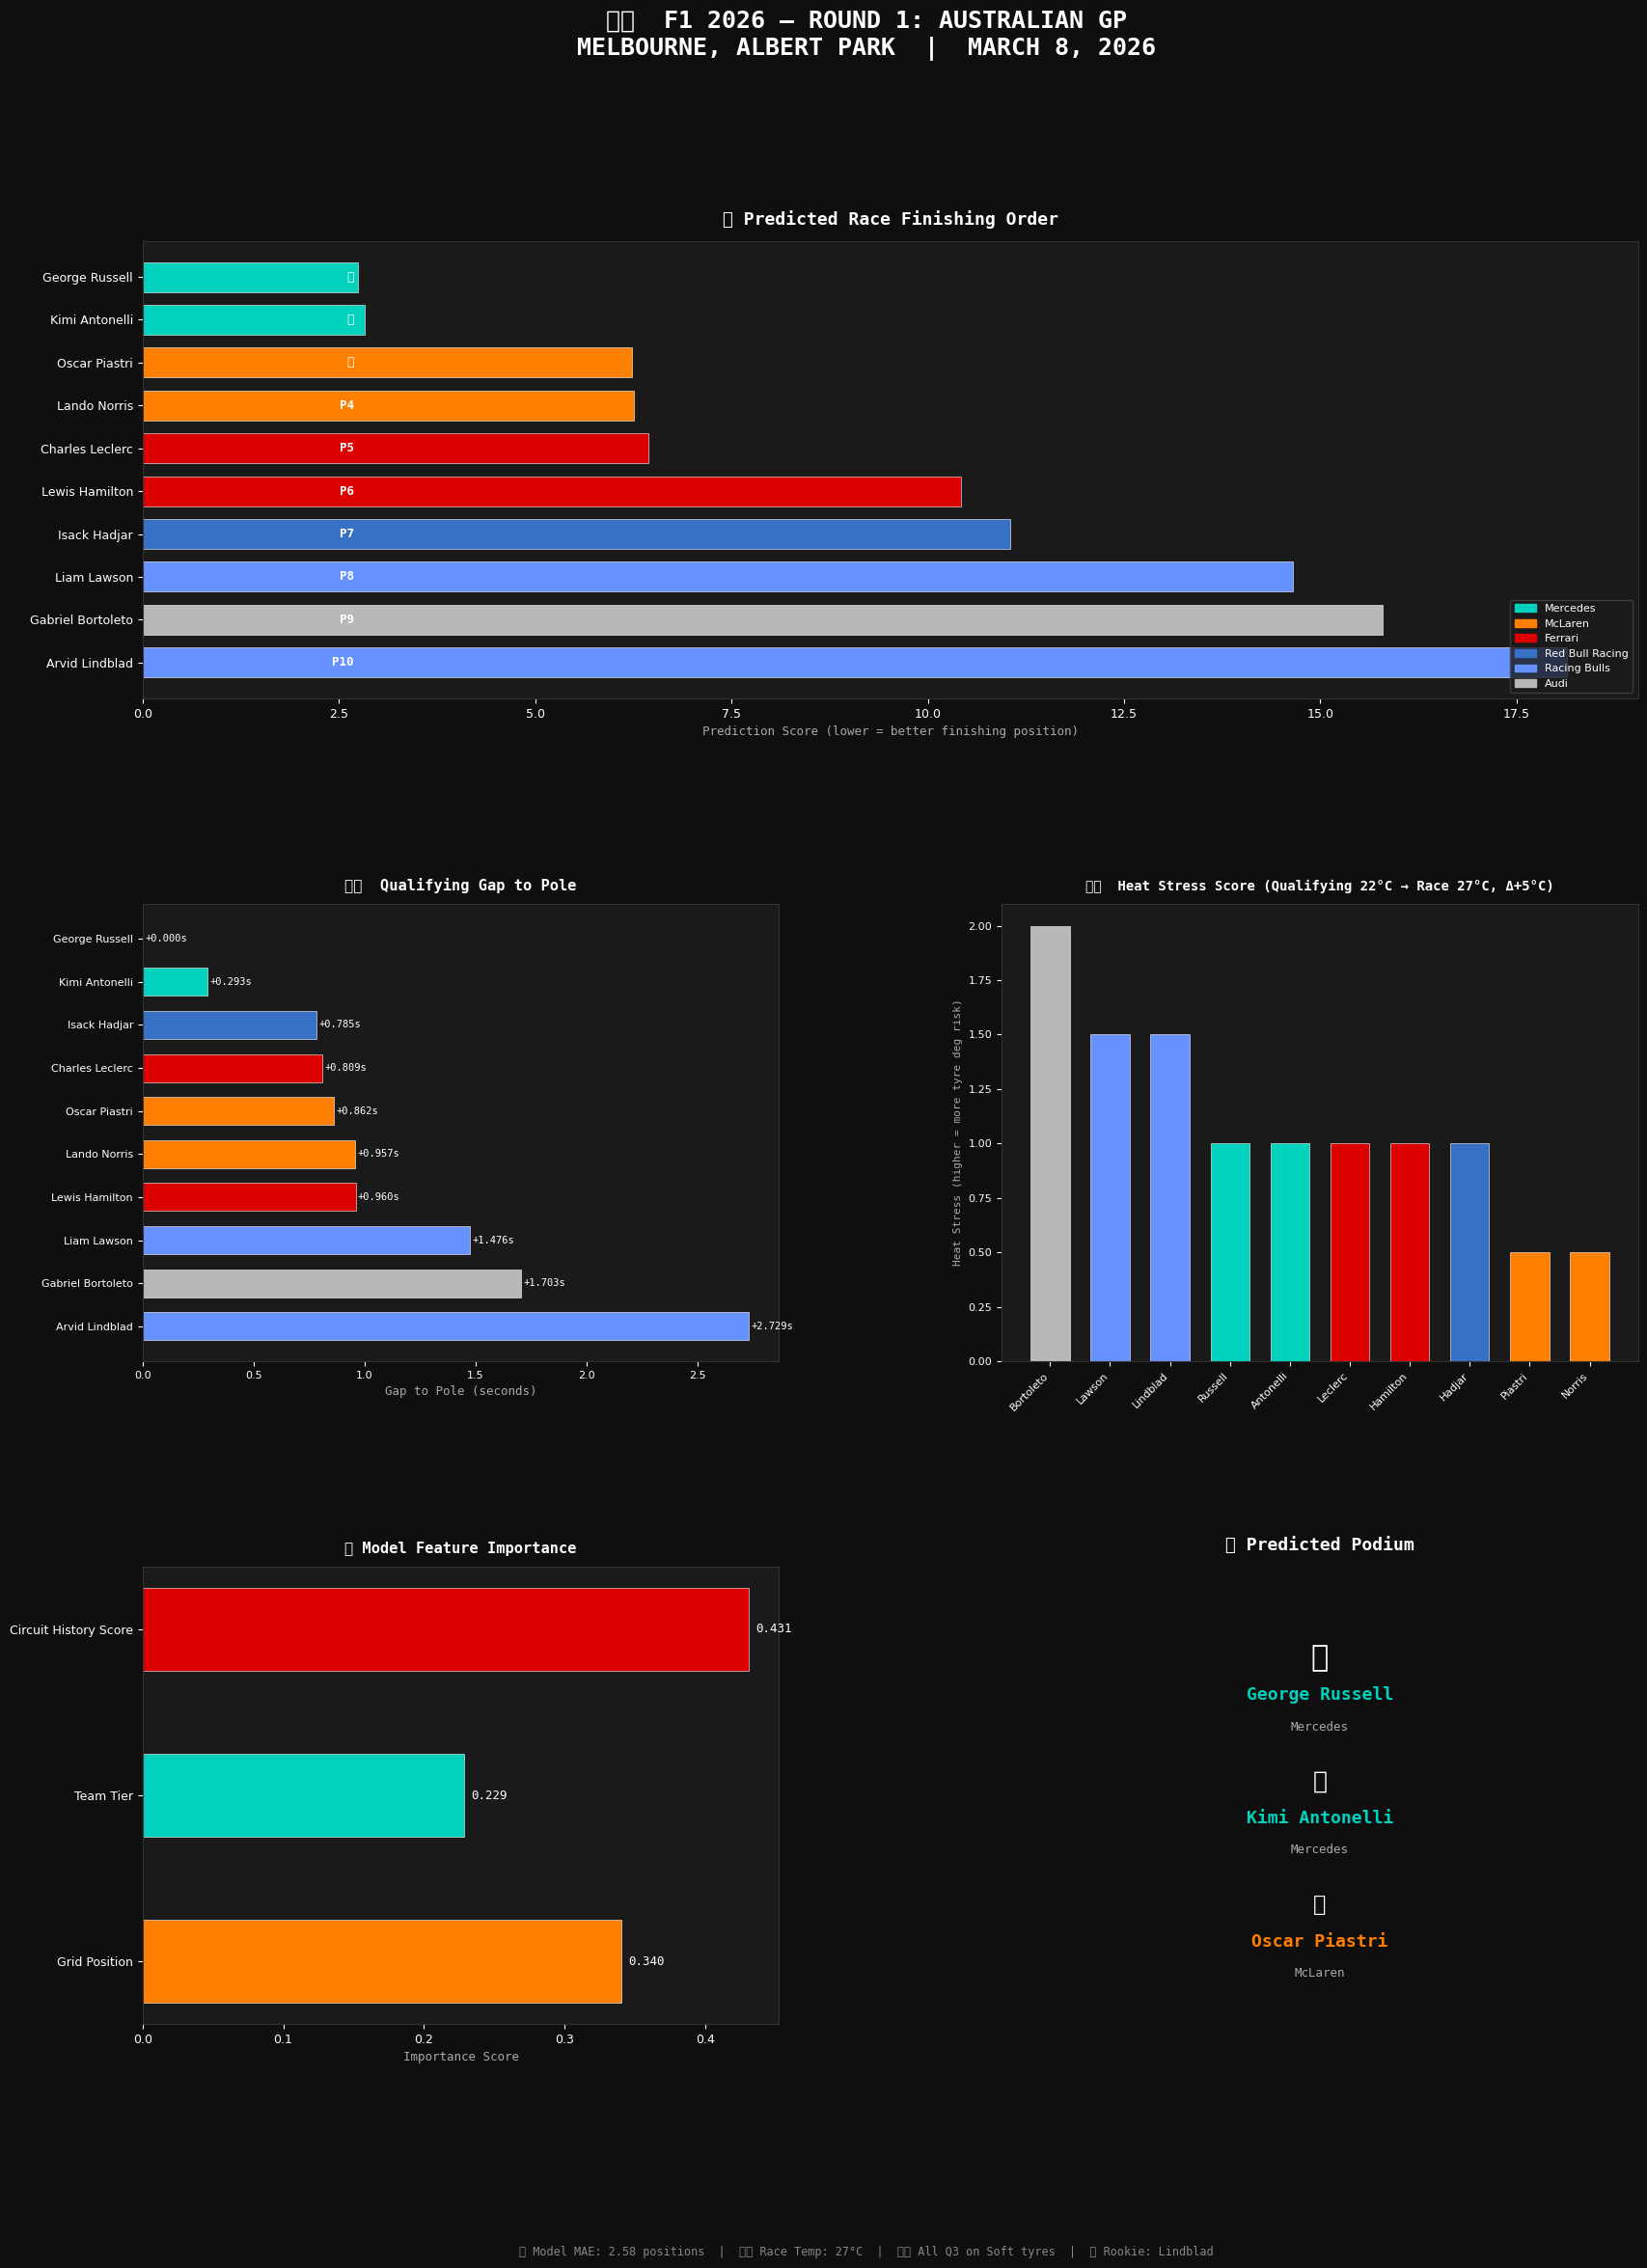

In [95]:
# ══════════════════════════════════════════════════════════
# 10. VISUALISATIONS
# ══════════════════════════════════════════════════════════
plt.style.use("dark_background")
FONT = "monospace"

driver_colors = [TEAM_COLORS.get(t, "#FFFFFF") for t in data["Team"]]

fig = plt.figure(figsize=(20, 24), facecolor="#0f0f0f")
fig.suptitle(
    "🏎️  F1 2026 — ROUND 1: AUSTRALIAN GP\nMELBOURNE, ALBERT PARK  |  MARCH 8, 2026",
    fontsize=18, fontweight="bold", color="white",
    fontfamily=FONT, y=0.98
)
gs = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Chart 1: Predicted Race Finishing Order ────────────────
ax1 = fig.add_subplot(gs[0, :])
bars = ax1.barh(
    data["Driver"][::-1],
    data["PredictedScore"][::-1],
    color=driver_colors[::-1],
    edgecolor="white", linewidth=0.4, height=0.7
)
ax1.set_title("📊 Predicted Race Finishing Order",
              fontsize=13, fontweight="bold", color="white",
              fontfamily=FONT, pad=12)
ax1.set_xlabel("Prediction Score (lower = better finishing position)",
               color="#AAAAAA", fontsize=9, fontfamily=FONT)
ax1.tick_params(colors="white", labelsize=9)
ax1.set_facecolor("#1a1a1a")
for spine in ax1.spines.values():
    spine.set_edgecolor("#333333")

# Add position labels
for i, (_, row) in enumerate(data[::-1].iterrows()):
    pos   = int(row["PredictedPosition"])
    label = medals.get(pos, f"P{pos}")
    ax1.text(
        data["PredictedScore"].min() * 0.98,
        i, label,
        va="center", ha="right", fontsize=9,
        color="white", fontfamily=FONT, fontweight="bold"
    )

# Team legend
seen = set()
legend_patches = []
for _, row in data.iterrows():
    t = row["Team"]
    if t not in seen:
        seen.add(t)
        legend_patches.append(
            mpatches.Patch(color=TEAM_COLORS.get(t, "#FFF"), label=t)
        )
ax1.legend(
    handles=legend_patches, loc="lower right",
    fontsize=8, facecolor="#1a1a1a", edgecolor="#444",
    labelcolor="white"
)

# ── Chart 2: Qualifying Gap to Pole ───────────────────────
ax2 = fig.add_subplot(gs[1, 0])
qual_data  = qualifying_2026.sort_values("GapToPole_s")
qual_colors = [TEAM_COLORS.get(t, "#FFFFFF") for t in qual_data["Team"]]
ax2.barh(
    qual_data["Driver"][::-1],
    qual_data["GapToPole_s"][::-1],
    color=qual_colors[::-1],
    edgecolor="white", linewidth=0.4, height=0.65
)
ax2.set_title("⏱️  Qualifying Gap to Pole",
              fontsize=11, fontweight="bold", color="white",
              fontfamily=FONT, pad=10)
ax2.set_xlabel("Gap to Pole (seconds)", color="#AAAAAA",
               fontsize=9, fontfamily=FONT)
ax2.tick_params(colors="white", labelsize=8)
ax2.set_facecolor("#1a1a1a")
for spine in ax2.spines.values():
    spine.set_edgecolor("#333333")

# Gap labels
for i, (_, row) in enumerate(qual_data[::-1].iterrows()):
    ax2.text(
        row["GapToPole_s"] + 0.01, i,
        f"+{row['GapToPole_s']:.3f}s",
        va="center", fontsize=7.5,
        color="white", fontfamily=FONT
    )

    # ── Chart 3: Heat Stress Score ────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
heat_data   = data.sort_values("HeatStressScore", ascending=False)
heat_colors = [TEAM_COLORS.get(t, "#FFFFFF") for t in heat_data["Team"]]
bars3 = ax3.bar(
    range(len(heat_data)),
    heat_data["HeatStressScore"],
    color=heat_colors,
    edgecolor="white", linewidth=0.4, width=0.65
)
ax3.set_title(f"🌡️  Heat Stress Score (Qualifying {QUALI_TEMP}°C → Race {RACE_TEMP}°C, Δ+{TEMP_DELTA}°C)",
              fontsize=10, fontweight="bold", color="white",
              fontfamily=FONT, pad=10)
ax3.set_ylabel("Heat Stress (higher = more tyre deg risk)",
               color="#AAAAAA", fontsize=8, fontfamily=FONT)
ax3.set_xticks(range(len(heat_data)))
ax3.set_xticklabels(
    [d.split()[-1] for d in heat_data["Driver"]],
    rotation=45, ha="right", fontsize=8, color="white"
)
ax3.tick_params(colors="white", labelsize=8)
ax3.set_facecolor("#1a1a1a")
for spine in ax3.spines.values():
    spine.set_edgecolor("#333333")

# ── Chart 4: Feature Importance ───────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
feat_names  = ["Grid Position", "Team Tier", "Circuit History Score"]
feat_import = model.feature_importances_
feat_colors = ["#FF8000", "#00D2BE", "#DC0000"]
bars4 = ax4.barh(feat_names, feat_import, color=feat_colors,
                 edgecolor="white", linewidth=0.4, height=0.5)
ax4.set_title("🤖 Model Feature Importance",
              fontsize=11, fontweight="bold", color="white",
              fontfamily=FONT, pad=10)
ax4.set_xlabel("Importance Score", color="#AAAAAA",
               fontsize=9, fontfamily=FONT)
ax4.tick_params(colors="white", labelsize=9)
ax4.set_facecolor("#1a1a1a")
for spine in ax4.spines.values():
    spine.set_edgecolor("#333333")
for i, v in enumerate(feat_import):
    ax4.text(v + 0.005, i, f"{v:.3f}", va="center",
             fontsize=9, color="white", fontfamily=FONT)

# ── Chart 5: Podium Prediction Highlight ──────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_facecolor("#1a1a1a")
ax5.axis("off")
for spine in ax5.spines.values():
    spine.set_edgecolor("#333333")

podium = data[data["PredictedPosition"] <= 3].sort_values("PredictedPosition")
ax5.set_title("🏆 Predicted Podium",
              fontsize=13, fontweight="bold", color="white",
              fontfamily=FONT, pad=12)

podium_y    = [0.72, 0.45, 0.18]
podium_icon = ["🥇", "🥈", "🥉"]
podium_size = [22, 18, 16]

for i, (_, row) in enumerate(podium.iterrows()):
    color = TEAM_COLORS.get(row["Team"], "#FFFFFF")
    ax5.text(0.5, podium_y[i] + 0.08,
             podium_icon[i],
             ha="center", va="center",
             fontsize=podium_size[i],
             transform=ax5.transAxes)
    ax5.text(0.5, podium_y[i],
             row["Driver"],
             ha="center", va="center",
             fontsize=13, fontweight="bold",
             color=color, fontfamily=FONT,
             transform=ax5.transAxes)
    ax5.text(0.5, podium_y[i] - 0.07,
             row["Team"],
             ha="center", va="center",
             fontsize=9, color="#AAAAAA",
             fontfamily=FONT,
             transform=ax5.transAxes)

# Footer
fig.text(
    0.5, 0.01,
    f"🔍 Model MAE: {mae:.2f} positions  |  "
    f"🌡️ Race Temp: {RACE_TEMP}°C  |  "
    f"🏎️ All Q3 on Soft tyres  |  "
    f"🆕 Rookie: Lindblad",
    ha="center", fontsize=8.5, color="#888888", fontfamily=FONT
)

plt.savefig(
    "round_01_australia_prediction.png",
    dpi=150, bbox_inches="tight",
    facecolor="#0f0f0f"
)
print("✅ Chart saved → round_01_australia_prediction.png")
plt.show()